In [1]:
import pandas as pd

# Contratos

In [2]:
YEAR = 2010

In [16]:
free_agents = pd.read_csv(f'data/raw/free_agents/transactions/{YEAR}_free_agents_transactions.csv')
free_agents.columns = free_agents.columns.str.lower()
#remove • in front of player's name and whitespace
free_agents.acquired = free_agents.acquired.str.replace('•', '').str.strip()
free_agents.relinquished = free_agents.relinquished.str.replace('•', '').str.strip()
free_agents.notes = free_agents.notes.str.lower()

In [17]:
free_agents

,date,team,acquired,relinquished,notes
0,2010-06-02,Magic,NaN,Matt Barnes,"player declined contract option, making him an..."
1,2010-06-25,Bobcats,Tyrus Thomas,NaN,"team tendered 1-year qualifying offer, making ..."
2,2010-06-28,Jazz,Kyrylo Fesenko,NaN,"team tendered qualifying offer, making player ..."
3,2010-06-28,Jazz,Wesley Matthews / Wes Matthews Jr.,NaN,"team tendered qualifying offer, making player ..."
4,2010-06-29,Celtics,NaN,Paul Pierce,"player declined contract option, making him an..."
...,...,...,...,...,...
437,2011-04-10,Rockets,Marcus Cousin (Lynn),NaN,signed free agent to a 3-year contract
438,2011-04-11,Hawks,Magnum Rolle,NaN,signed free agent for the remainder of the sea...
439,2011-04-12,Blazers,Earl Barron,NaN,signed free agent for the remainder of the sea...
440,2011-04-12,Lakers,Trey Johnson,NaN,signed free agent for the remainder of the season


In [ ]:
import re

# Define a function to extract year and money
def extract_year_money(notes):
    match = re.search(r'signed .* (\d+)-year.*\$(\d.*(m|k))', notes)
    if match:
        return pd.Series([int(match.group(1)), match.group(2)])
    else:
        return pd.Series([None, None])

In [22]:
free_agents.tail(30)

,date,team,acquired,relinquished,notes,contract_years,contract_value
412,2011-03-02,Heat,Mike Bibby,NaN,signed free agent,NaN,None
413,2011-03-03,Bobcats,Dominic McGuire,NaN,signed free agent,NaN,None
414,2011-03-03,Bulls,Rasual Butler,NaN,signed free agent,NaN,None
415,2011-03-03,Celtics,Aleksandar Pavlovic / Sasha Pavlovic,NaN,signed free agent,NaN,None
416,2011-03-03,Mavericks,Corey Brewer,NaN,"signed free agent to a 3-year, $7.5m contract",3.0,7.
417,2011-03-03,Spurs,Othyus Jeffers,NaN,signed free agent to a 10-day contract,NaN,None
418,2011-03-03,Warriors,Al Thornton,NaN,signed free agent,NaN,None
419,2011-03-05,Celtics,Carlos Arroyo,NaN,signed free agent,NaN,None
420,2011-03-05,Grizzlies,Leon Powe,NaN,signed free agent,NaN,None
421,2011-03-07,Bobcats,Garrett Temple,NaN,signed free agent to a 10-day contract,NaN,None


In [13]:
contracts = pd.read_csv('data/raw/contracts/sportrac/2011_contracts.csv')
contracts[contracts.Player.str.contains('Bosh')]

,Player,Pos,Team,Age,Yrs,Dollars,G'teed,G'teed %,Average,Free Agent
2,BoshChris Bosh (2014-2018),C,MIA,30,5,"$118,705,300","$118,705,300",100.00%,"$23,741,060",2019


In [3]:
unsigned_free_agents = pd.read_csv('data/raw/free_agents/unsigned/2018_unsigned_free_agents.csv')

In [4]:
UNSIGNED_FREE_AGENTS_COLUMNS = ['player', 'position', 'age', 'yoe', 'prev_team', 'prev_avg_value', 'type']
unsigned_free_agents.columns = UNSIGNED_FREE_AGENTS_COLUMNS
unsigned_free_agents.drop(columns=['position', 'yoe'], inplace=True)
unsigned_free_agents['prev_avg_value'] = unsigned_free_agents['prev_avg_value'].str.replace('$', '').str.replace(',', '').astype(float)
unsigned_free_agents

,player,age,prev_team,prev_avg_value,type
0,Al Jefferson,33.1,IND,10000000.0,UFA
1,Cole Aldrich,29.2,MIN,7300000.0,UFA
2,Alan Williams,25.0,PHX,5666667.0,UFA
3,Kyle Singler,29.8,OKC,4750000.0,UFA
4,Mario Hezonja,22.9,ORL,3909880.0,UFA / Bird
...,...,...,...,...,...
80,Marcus Paige,24.3,CHA,0.0,UFA / Non-Bird
81,Xavier Munford,25.7,MIL,0.0,UFA / Non-Bird
82,Marshall Plumlee,25.5,MIL,0.0,UFA / Non-Bird
83,Isaiah Hicks,23.5,NYK,0.0,RFA / Non-Bird


In [35]:
free_agents = pd.read_csv('data/raw/free_agents/signed/2018_signed_free_agents.csv')

In [36]:
FREE_AGENTS_COLUMNS = ['rank', 'player', 'position', 'age', 'yoe', 'team_from', 'team_to', 'years_of_contract', 'total_value', 'avg_value', 'status']
free_agents.columns = FREE_AGENTS_COLUMNS
# Drop rank and position columns
free_agents.drop(columns=['rank', 'position', 'yoe'], inplace=True)
# Drop rows with NaN values
free_agents.dropna(how='all', inplace=True)
# Replace $ and , in total_value and avg_value columns
free_agents['total_value'] = free_agents['total_value'].str.replace('$', '').str.replace(',', '').astype(int)
free_agents['avg_value'] = free_agents['avg_value'].str.replace('$', '').str.replace(',', '').fillna(0).astype(int)
# Replace the first part of the name in player column
free_agents['player'] = free_agents['player'].str.replace('.*\n', '', regex=True)


In [37]:
free_agents

,player,age,team_from,team_to,years_of_contract,total_value,avg_value,status
0,Chris Paul,32.8,HOU,HOU,4.0,159730592,39932648,Official
1,LeBron James,33.1,CLE,LAL,4.0,153312846,38328212,Official
2,Nikola Jokic,22.9,DEN,DEN,5.0,147710050,29542010,Official
3,Paul George,27.8,OKC,OKC,4.0,136911936,34227984,Official
4,Aaron Gordon,22.3,ORL,ORL,4.0,80000000,20000000,Official
...,...,...,...,...,...,...,...,...
102,Troy Williams,23.1,NYK,NOP,1.0,1512601,1512601,Official
103,Kay Felder,22.8,DET,TOR,1.0,1512601,1512601,Official
104,Ryan Arcidiacono,23.8,CHI,CHI,1.0,1349383,1349383,Official
105,Kyle Collinsworth,26.3,DAL,TOR,1.0,1349383,1349383,Official


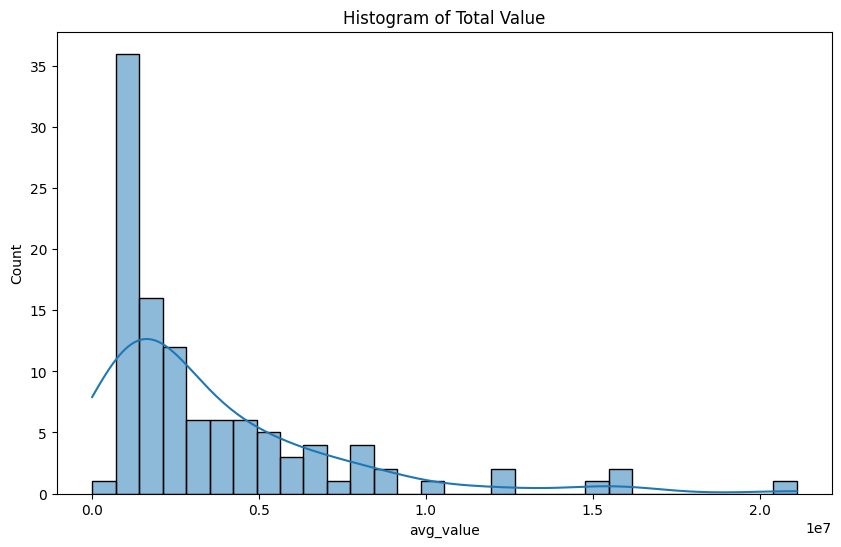

In [31]:
#plot histogram of total_value and avg_value
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(free_agents['avg_value'], bins=30, kde=True)
plt.title('Histogram of Total Value')
plt.show()